## Module: Data Preprocessing & Feature Engineering

**Objective:** This notebook executes the data cleaning and filtering pipeline for the Kaggle Spotify Tracks Dataset. The finalized data is optimized for multimodal semantic matching using the CLIP model.

**Key Operations:**
* **Data Ingestion:** Automated retrieval via Kaggle API.
* **Quality Control:** Removal of null values and irrelevant audio tracks (e.g., spoken-word content).
* **Deduplication & Aggregation:** Consolidation of duplicate tracks and aggregation of overlapping genres to preserve semantic richness.
* **Feature Engineering:** Construction of composite text descriptions (`clip_metadata`) to align with visual embeddings.

In [1]:
import subprocess, sys, os, pathlib, shutil

# Install kaggle CLI if not already available
subprocess.run([sys.executable, '-m', 'pip', 'install', 'kaggle', '--quiet'], check=True)

# Copy kaggle.json from Downloads to ~/.kaggle/
src = pathlib.Path.home() / 'Downloads' / 'kaggle.json'
dst = pathlib.Path.home() / '.kaggle' / 'kaggle.json'
dst.parent.mkdir(exist_ok=True)
shutil.copy(src, dst)
os.chmod(dst, 0o600)

# Download and extract the dataset
!kaggle datasets download maharshipandya/-spotify-tracks-dataset
!unzip -o -q ./-spotify-tracks-dataset.zip
print("Download complete. Files:", [f for f in os.listdir('.') if f.endswith('.csv')])

python(68409) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


Dataset URL: https://www.kaggle.com/datasets/maharshipandya/-spotify-tracks-dataset
License(s): ODbL-1.0
-spotify-tracks-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)


python(68411) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


Download complete. Files: ['dataset.csv']


In [2]:
import pandas as pd

df = pd.read_csv('../data/dataset.csv', index_col=0)

print("Initial Dataset Shape:", df.shape)
display(df.head())

Initial Dataset Shape: (114000, 20)


,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


---
### Brief EDA

In [3]:
null_counts = df.isnull().sum()
print(f"Null values per column (out of {len(df):,} rows):\n")
print(null_counts[null_counts > 0].to_string() if null_counts.any() else "No nulls found.")

Null values per column (out of 114,000 rows):

artists       1
album_name    1
track_name    1


In [4]:
genres = df['track_genre'].value_counts()
print(f"Total unique genres: {len(genres)}\n")
print(genres.to_string())

Total unique genres: 114

track_genre
acoustic             1000
punk-rock            1000
progressive-house    1000
power-pop            1000
pop                  1000
pop-film             1000
piano                1000
party                1000
pagode               1000
opera                1000
new-age              1000
mpb                  1000
minimal-techno       1000
metalcore            1000
metal                1000
mandopop             1000
malay                1000
latino               1000
latin                1000
kids                 1000
k-pop                1000
jazz                 1000
j-rock               1000
j-pop                1000
j-idol               1000
j-dance              1000
iranian              1000
psych-rock           1000
punk                 1000
afrobeat             1000
r-n-b                1000
turkish              1000
trip-hop             1000
trance               1000
techno               1000
tango                1000
synth-pop            1000


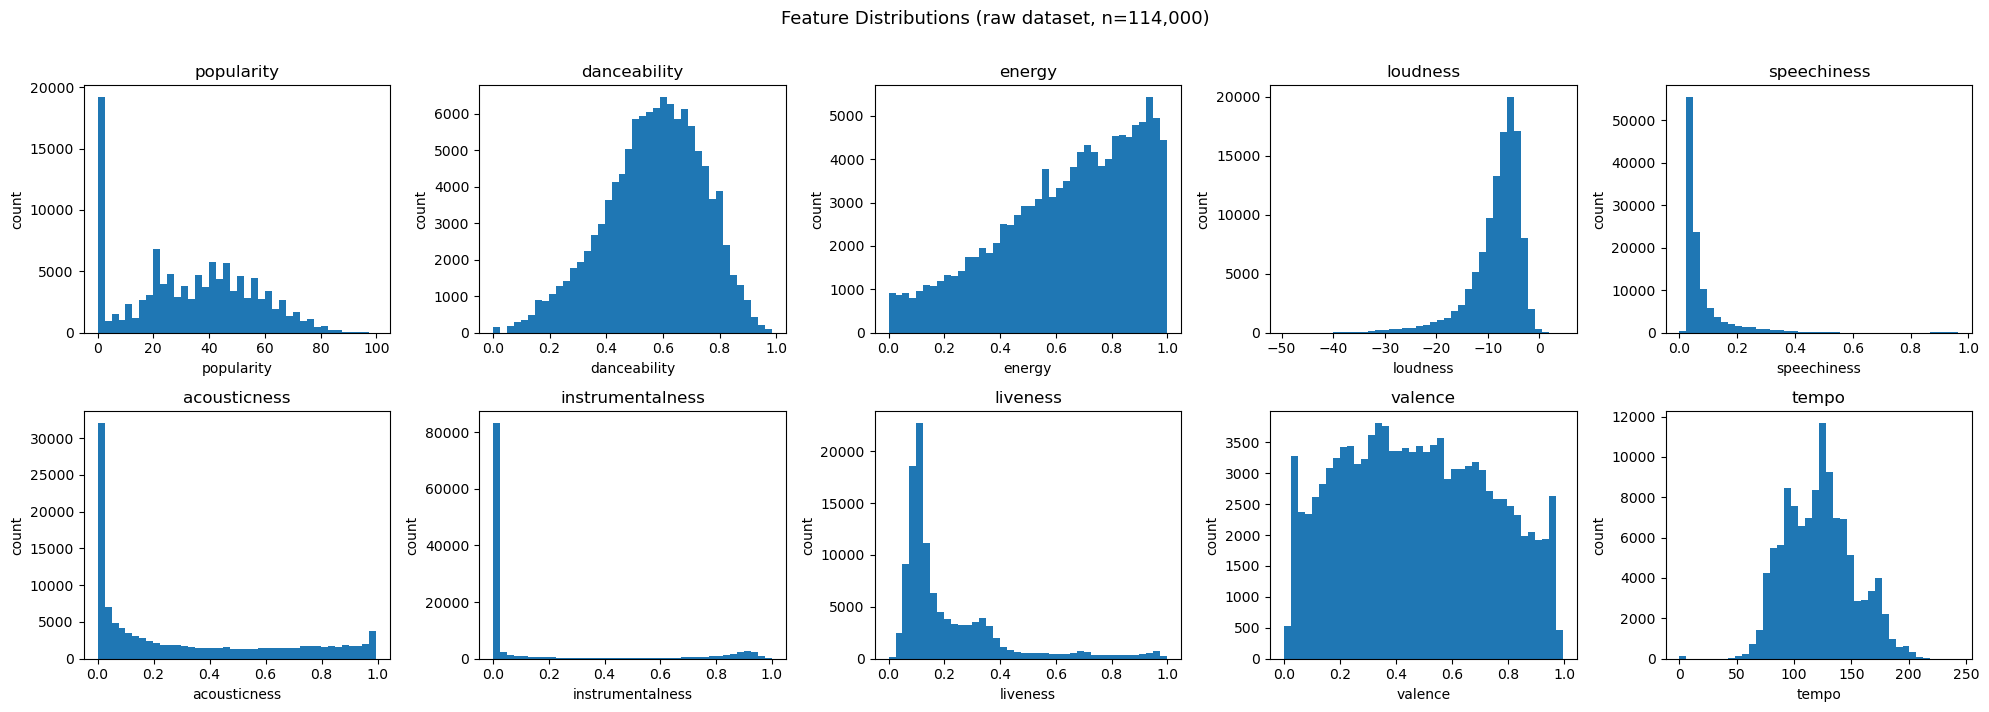

In [5]:
import matplotlib.pyplot as plt

features = ['popularity', 'danceability', 'energy', 'loudness',
            'speechiness', 'acousticness', 'instrumentalness',
            'liveness', 'valence', 'tempo']

fig, axes = plt.subplots(2, 5, figsize=(20, 7))
axes = axes.flatten()

for ax, col in zip(axes, features):
    ax.hist(df[col].dropna(), bins=40, edgecolor='none')
    ax.set_title(col)
    ax.set_xlabel(col)
    ax.set_ylabel('count')

fig.suptitle('Feature Distributions (raw dataset, n=114,000)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

---
### Representation Strategy: Natural-Language Descriptions

We represent each song as a **natural-language sentence** rather than a raw feature vector.
This is a deliberate design choice for CLIP compatibility:

- CLIP's text encoder was trained on image captions, not numeric arrays.
  Feeding it raw floats (`danceability=0.82`) would produce meaningless embeddings.
- Converting audio features to descriptive prose (`"an upbeat acoustic track with a
  relaxed groove, suited for a quiet afternoon"`) places the song in the same semantic
  space as natural scene descriptions, enabling direct cosine comparison with image embeddings.
- We use **numeric features only as signals** to select the right words — the final
  representation is entirely text.

The `build_clip_description()` function below constructs a full sentence per track,
targeting the kind of descriptive language CLIP understands best.


---
### Data Preprocessing

In [6]:
# 1. Handle missing values and sort by priority metric (popularity)
df_clean = df.dropna().copy()
df_clean = df_clean.sort_values('popularity', ascending=False)

# 2. Feature Aggregation: Consolidate overlapping genres for identical tracks
df_clean['merged_genres'] = df_clean.groupby(['track_name', 'artists'])['track_genre'].transform(
    lambda x: ', '.join(x.unique())
)

# 3. Deduplication: Retain the primary record containing the aggregated genre data
df_clean = df_clean.drop_duplicates(subset=['track_name', 'artists'], keep='first')

# 4. Apply content and quality filters
mask_music   = df_clean['speechiness'] < 0.66
mask_popular = df_clean['popularity'] > 20
df_filtered  = df_clean[mask_music & mask_popular].copy()


# 5. Build richer CLIP-compatible natural-language descriptions
# ─────────────────────────────────────────────────────────────
# Design rationale: CLIP's text encoder was trained on image captions, so it
# understands descriptive prose far better than formulaic keyword lists.
# Each function below maps a numeric feature range to the kind of evocative
# language that appears in real music writing and image captions.

def _mood_phrase(valence: float, energy: float) -> str:
    """Combine valence + energy into a single mood sentence fragment."""
    if valence >= 0.70 and energy >= 0.70:
        return 'euphoric and exhilarating, full of joy and momentum'
    if valence >= 0.65 and energy < 0.50:
        return 'warm and content, like a quiet happy afternoon'
    if valence >= 0.50 and energy >= 0.65:
        return 'upbeat and energising, with a positive driving feel'
    if valence <= 0.25 and energy <= 0.30:
        return 'deeply melancholic and introspective, heavy with emotion'
    if valence <= 0.30 and energy >= 0.60:
        return 'intense and brooding, dark energy with emotional weight'
    if valence <= 0.40 and energy <= 0.45:
        return 'melancholic and reflective, with a bittersweet sadness'
    if valence >= 0.45 and energy <= 0.30:
        return 'calm and gentle, peaceful with a soft warmth'
    return 'emotionally balanced, with a measured and understated feel'


def _texture_phrase(acousticness: float, instrumentalness: float, danceability: float) -> str:
    """Describe sonic texture from acousticness, instrumentalness, danceability."""
    parts = []
    if acousticness >= 0.75:
        parts.append('acoustic and organic in texture')
    elif acousticness <= 0.10:
        parts.append('produced with a sleek electronic sound')
    else:
        parts.append('blending acoustic and electronic elements')

    if instrumentalness >= 0.60:
        parts.append('entirely instrumental with no vocals')
    elif danceability >= 0.78:
        parts.append('with a groove designed to make you move')
    elif danceability <= 0.35:
        parts.append('with a loose unhurried rhythmic feel')

    return ', '.join(parts)


def _tempo_phrase(tempo: float, energy: float) -> str:
    """Describe pace in natural language."""
    if tempo >= 160:
        return 'at a racing, breathless pace'
    if tempo >= 130 and energy >= 0.65:
        return 'at a fast energetic tempo'
    if tempo >= 110:
        return 'at a steady mid-tempo groove'
    if tempo <= 70:
        return 'at a slow, unhurried tempo that invites stillness'
    if tempo <= 90:
        return 'at a relaxed, laid-back pace'
    return 'at a moderate tempo'


def _setting_phrase(vibe_key: str) -> str:
    """Map genre clusters to an evocative listening-context sentence."""
    genre_settings = {
        'acoustic':       'perfect for an intimate acoustic session or quiet evening at home',
        'jazz':           'evoking a dimly lit jazz bar or a late-night piano lounge',
        'classical':      'suited to a concert hall or a focused, quiet study session',
        'electronic':     'fitting for a late-night drive or a buzzing club dancefloor',
        'dance':          'made for a packed dancefloor with pulsing lights',
        'pop':            'at home on a sunny playlist or a feel-good road trip',
        'hip-hop':        'carrying the energy of a city street or an after-hours session',
        'rap':            'carrying the energy of a city street or an after-hours session',
        'r-n-b':          'suited to a late-night R&B set or a romantic evening',
        'soul':           'warm enough for a candlelit dinner or a soulful Sunday morning',
        'indie':          'fitting for a rainy afternoon or a small intimate venue',
        'folk':           'evoking open roads, campfires, and quiet countryside',
        'country':        'evoking open roads, campfires, and quiet countryside',
        'blues':          'dripping with late-night blues bar atmosphere',
        'rock':           'built for a live stage, a loud room, or a high-speed drive',
        'metal':          'intense enough for a mosh pit or a cathartic release',
        'latin':          'bringing warmth and rhythm to a summer gathering',
        'reggae':         'conjuring a sun-drenched beach or a breezy outdoor festival',
        'ambient':        'dissolving into a quiet room, a meditation, or a slow sunset',
        'study':          'calm enough to fade into the background of focused work',
        'sleep':          'gentle enough to drift into sleep or deep relaxation',
        'chill':          'relaxed and easygoing, perfect for unwinding',
        'workout':        'high-intensity enough to push through a hard workout',
        'party':          'energetic enough to keep a party going all night',
        'romance':        'intimate and tender, ideal for a romantic setting',
        'sad':            'carrying a quiet sadness suited to reflective solitude',
        'happy':          'bright and cheerful, lifting the mood of any room',
    }
    v = vibe_key.lower()
    for keyword, phrase in genre_settings.items():
        if keyword in v:
            return phrase
    return 'fitting for a wide range of moods and settings'


def build_clip_description(row) -> str:
    """
    Build a rich natural-language description of a track optimised for CLIP.

    Output format (example):
        'A melancholic and reflective indie acoustic track by Phoebe Bridgers,
         acoustic and organic in texture, at a slow unhurried tempo, evoking
         a rainy afternoon or a small intimate venue.'

    Rationale: CLIP embeds text the same way it embeds image captions.
    Descriptive prose about mood, texture, and setting aligns far better
    with visual scene embeddings than raw feature keywords.
    """
    mood    = _mood_phrase(row['valence'], row['energy'])
    texture = _texture_phrase(row['acousticness'], row['instrumentalness'], row['danceability'])
    tempo   = _tempo_phrase(row['tempo'], row['energy'])
    setting = _setting_phrase(str(row.get('merged_genres', '')))

    # Primary genre label (first token before comma)
    genre_label = str(row.get('merged_genres', 'music')).split(',')[0].strip()

    return (
        f"A {mood} {genre_label} track by {row['artists']}, "
        f"{texture}, {tempo}, {setting}."
    )


df_filtered['clip_metadata'] = df_filtered.apply(build_clip_description, axis=1)

# Validation: show sample descriptions
print("Sample clip_metadata descriptions (richer natural-language format):\n")
for _, row in df_filtered.sample(4, random_state=7).iterrows():
    print(f"Track   : {row['track_name']} — {row['artists']}")
    print(f"Genres  : {row['merged_genres']}")
    print(f"Metadata: {row['clip_metadata']}")
    print()


Sample clip_metadata descriptions (richer natural-language format):

Track   : Cold — Before I Turn
Genres  : death-metal
Metadata: A intense and brooding, dark energy with emotional weight death-metal track by Before I Turn, produced with a sleek electronic sound, at a fast energetic tempo, intense enough for a mosh pit or a cathartic release.

Track   : Summer — Calvin Harris
Genres  : house, electro, progressive-house
Metadata: A euphoric and exhilarating, full of joy and momentum house track by Calvin Harris, produced with a sleek electronic sound, at a steady mid-tempo groove, fitting for a wide range of moods and settings.

Track   : Llegastes Tarde — Tito Gomez
Genres  : salsa
Metadata: A warm and content, like a quiet happy afternoon salsa track by Tito Gomez, blending acoustic and electronic elements, at a moderate tempo, fitting for a wide range of moods and settings.

Track   : Important Words — Gene Vincent & His Blue Caps
Genres  : rockabilly
Metadata: A melancholic and re

In [7]:
# Display final schema attributes
print("Final Dataset Columns:")
print(df_filtered.columns.tolist())

Final Dataset Columns:
['track_id', 'artists', 'album_name', 'track_name', 'popularity', 'duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature', 'track_genre', 'merged_genres', 'clip_metadata']


In [8]:
import pathlib

output_path = pathlib.Path('..') / 'data' / 'spotify_cleaned_final.csv'
df_filtered.to_csv(output_path, index=False)